# FET Model Fitting, Comparison, and Posterior Predictive Checks

This notebook demonstrates the complete workflow:
1. Load and prepare data
2. Fit all candidate models
3. Compare models using fit metrics
4. Generate comprehensive PPC for the winning model
5. Extract and visualize subject-level parameters

## 1. Setup and Configuration

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# FET Models imports
from fet_models import (
    configure_device,
    FETExponential,
    FETHyperbolic,
    FETLinear,
    FETQuadratic,
    FETExponentialBias,
    ThreatOnly,
    EffortOnly,
    ModelFitter,
    fit_models_parallel,
    load_fitted_models,
)
from fet_models.ppc import PosteriorPredictive

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')


sys.path.append("/home/nokada/projects/LIMA_Analysis_clean/Code/Modeling/behavior_2/plotter")
import plotter
from plotter import plot_delta_ic_comparison
# Output directory
OUTPUT_DIR = Path('/home/nokada/projects/LIMA_Analysis_clean/Code/Modeling/behavior_2/CLEAN_ATTEMPT/results')
OUTPUT_DIR.mkdir(exist_ok=True)

print("Imports successful!")

Imports successful!


In [17]:
# Configure device - SET THIS BASED ON YOUR HARDWARE
USE_GPU = True  # Set to False if no GPU available

configure_device(use_gpu=USE_GPU, gpu_memory_fraction=0.9)

GPU configured: cuda:0


CudaDevice(id=0)

## 2. Load Data

In [18]:
data = pd.read_csv('/home/nokada/projects/LIMA_analysis/Code/Data/behavior_270.csv')

def calculate_distance_H(row):
    if row['effort_H'] == 0.6:
        return 1
    elif row['effort_H'] == 0.8:
        return 2
    elif row['effort_H'] == 1.0:
        return 3
    else:
        return np.nan
    
data['distance_H'] = data.apply(calculate_distance_H, axis=1)
data['distance_L'] = 1

print(f"Data loaded: {len(data)} trials, {data['subj'].nunique()} subjects")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nChoice distribution: {data['choice'].value_counts().to_dict()}")
data.head()

Data loaded: 12150 trials, 270 subjects

Columns: ['subj', 'trial', 'threat', 'effort_L', 'effort_H', 'choice', 'outcome', 'vigor', 'log_vigor', 'distance_H', 'distance_L']

Choice distribution: {0: 7038, 1: 5112}


,subj,trial,threat,effort_L,effort_H,choice,outcome,vigor,log_vigor,distance_H,distance_L
0,1,1,0.1,0.4,1.0,0,0,0.836241,-0.178839,3,1
1,1,2,0.9,0.4,0.8,0,0,0.973095,-0.027273,2,1
2,1,3,0.5,0.4,1.0,0,0,0.812073,-0.208165,3,1
3,1,4,0.9,0.4,1.0,0,0,1.005805,0.005788,3,1
4,1,5,0.1,0.4,0.8,0,0,0.883973,-0.123329,2,1


In [19]:
# Quick data summary
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"N subjects: {data['subj'].nunique()}")
print(f"N trials: {len(data)}")
print(f"Trials per subject: {data.groupby('subj').size().mean():.0f}")
print(f"\nThreat levels: {sorted(data['threat'].unique())}")
print(f"Effort H range: [{data['effort_H'].min():.2f}, {data['effort_H'].max():.2f}]")
print(f"Effort L range: [{data['effort_L'].min():.2f}, {data['effort_L'].max():.2f}]")
print(f"Distance H range: [{data['distance_H'].min():.2f}, {data['distance_H'].max():.2f}]")
print(f"Distance L range: [{data['distance_L'].min():.2f}, {data['distance_L'].max():.2f}]")
print(f"\nP(High choice): {data['choice'].mean():.3f}")

DATA SUMMARY
N subjects: 270
N trials: 12150
Trials per subject: 45

Threat levels: [np.float64(0.1), np.float64(0.5), np.float64(0.9)]
Effort H range: [0.60, 1.00]
Effort L range: [0.40, 0.40]
Distance H range: [1.00, 3.00]
Distance L range: [1.00, 1.00]

P(High choice): 0.421


## 3. Define Models to Fit

In [20]:
# Define all candidate models
models_to_fit = {
    # Full models (effort + threat)
    'FET_Exponential': FETExponential(),
    'FET_Hyperbolic': FETHyperbolic(),
    'FET_Linear': FETLinear(),
    'FET_Quadratic': FETQuadratic(),
    
    # Model with bias term
    'FET_Exp_Bias': FETExponentialBias(),
    
    # Ablation models
    'Threat_Only': ThreatOnly(),
    'Effort_Only': EffortOnly(discount='exponential'),
}

print(f"Models to fit: {len(models_to_fit)}")
for name, model in models_to_fit.items():
    print(f"  - {name}: effort={model.use_effort_component}, threat={model.use_threat_component}")

Models to fit: 7
  - FET_Exponential: effort=True, threat=True
  - FET_Hyperbolic: effort=True, threat=True
  - FET_Linear: effort=True, threat=True
  - FET_Quadratic: effort=True, threat=True
  - FET_Exp_Bias: effort=True, threat=True
  - Threat_Only: effort=False, threat=True
  - Effort_Only: effort=True, threat=False


## 4. Fit All Models

Choose between:
- **Parallel fitting**: Faster if you have GPU with enough memory
- **Sequential fitting**: Safer, works on any hardware

In [21]:
# MCMC configuration
MCMC_CONFIG = {
    'num_warmup': 2000,      
    'num_samples': 4000,    
    'num_chains': 4,
    'target_accept_prob': 0.90,
    'R_H': 5.0,
    'R_L': 1.0,
    'C': 5.0,
}

SAVE_DIR = OUTPUT_DIR / 'model_fits'
print(f"Results will be saved to: {SAVE_DIR}")

Results will be saved to: /home/nokada/projects/LIMA_Analysis_clean/Code/Modeling/behavior_2/CLEAN_ATTEMPT/results/model_fits


In [ ]:
USE_PARALLEL = True  # Set to False for sequential fitting
N_PARALLEL = 2       # Number of models to fit simultaneously

if USE_PARALLEL:
    print("Using PARALLEL fitting...")
    fitted_models = fit_models_parallel(
        models_to_fit,
        data,
        n_parallel=N_PARALLEL,
        save_dir=str(SAVE_DIR),
        use_gpu=USE_GPU,
        **MCMC_CONFIG
    )
else:
    # Option B: SEQUENTIAL FITTING (safer, works on any hardware)
    print("Using SEQUENTIAL fitting...")
    fitted_models = {}
    
    for name, model in models_to_fit.items():
        print(f"\n{'='*60}")
        print(f"Fitting: {name}")
        print('='*60)
        
        fitter = ModelFitter(model)
        fitter.fit(data, **MCMC_CONFIG)
        fitter.save(SAVE_DIR / f"{name}_fit.pkl")
        fitted_models[name] = fitter
    
    # Also save the data
    data.to_pickle(SAVE_DIR / 'original_data.pkl')

print(f"\n✓ All {len(fitted_models)} models fitted!")

In [22]:
# Alternative: LOAD PREVIOUSLY FITTED MODELS
# Uncomment if you want to skip fitting and load saved models

fitted_models, data = load_fitted_models(str(SAVE_DIR), load_data=True)
print(f"Loaded {len(fitted_models)} models")

Loading 7 models from /home/nokada/projects/LIMA_Analysis_clean/Code/Modeling/behavior_2/CLEAN_ATTEMPT/results/model_fits...
Data: 12150 trials, 270 subjects
  FET_Quadratic: ['k', 'k_raw', 'z', 'z_raw']
  FET_Hyperbolic: ['k', 'k_raw', 'z', 'z_raw']
  FET_Linear: ['k', 'k_raw', 'z', 'z_raw']
  Threat_Only: ['z', 'z_raw']
  FET_Exp_Bias: ['beta', 'beta_raw', 'k', 'k_raw', 'z', 'z_raw']
  Effort_Only: ['k', 'k_raw']
  FET_Exponential: ['k', 'k_raw', 'z', 'z_raw']
Loaded 7 models


## 5. Model Comparison (with WAIC)

In [ ]:
# Import the compare_models function
from fet_models.ppc import compare_models, compute_waic

# Compare all models using WAIC + fit metrics
comparison_df = compare_models(fitted_models, data, n_draws=500)

print("="*100)
print("MODEL COMPARISON (sorted by WAIC - lower is better)")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)
print("\nKey metrics:")
print("  WAIC: Widely Applicable Information Criterion (lower = better, penalizes complexity)")
print("  dWAIC: Difference from best model")
print("  p_waic: Effective number of parameters")
print("  lppd: Log pointwise predictive density")

In [25]:
comparison_df.head(
    
)

,Model,WAIC,dWAIC,WAIC_se,p_waic,lppd,Brier,ECE,McFadden_R2,Accuracy,AUC
0,FET_Exp_Bias,9845.351326,0.000000,120.992887,499.211262,-4423.464401,0.115780,0.025127,0.465018,0.834156,0.916360
1,FET_Exponential,11770.349705,1924.998379,112.767536,340.897138,-5544.277714,0.150478,0.071770,0.329465,0.746091,0.865580
2,FET_Quadratic,11889.924830,2044.573504,115.386827,362.156672,-5582.805743,0.149252,0.067983,0.324805,0.791276,0.867307
3,FET_Hyperbolic,12012.113257,2166.761931,110.223074,291.673971,-5714.382657,0.156358,0.096614,0.308892,0.752593,0.859938
4,FET_Linear,12432.303437,2586.952111,109.061348,240.844636,-5975.307083,0.163298,0.110686,0.277336,0.754321,0.852585


In [26]:
# Store predictions for later use
comparison_results = {}
for name, fitter in fitted_models.items():
    ppc = PosteriorPredictive(fitter)
    pred_df = ppc.predict(data, n_draws=500)
    metrics = ppc.compute_fit_metrics(data, pred_df)
    waic = compute_waic(fitter, data, n_draws=500)
    comparison_results[name] = {
        'fitter': fitter,
        'pred_df': pred_df,
        'metrics': metrics,
        'waic': waic
    }

Generating predictions: 500 draws x 12150 trials
  Chunk 5/5 complete
Predictions complete
Generating predictions: 500 draws x 12150 trials
  Chunk 5/5 complete
Predictions complete
Generating predictions: 500 draws x 12150 trials
  Chunk 5/5 complete
Predictions complete
Generating predictions: 500 draws x 12150 trials
  Chunk 5/5 complete
Predictions complete
Generating predictions: 500 draws x 12150 trials
  Chunk 5/5 complete
Predictions complete
Generating predictions: 500 draws x 12150 trials
  Chunk 5/5 complete
Predictions complete
Generating predictions: 500 draws x 12150 trials
  Chunk 5/5 complete
Predictions complete


In [30]:
import importlib
import plotter  # or whatever your module import is

importlib.reload(plotter)
from plotter import plot_delta_ic_comparison

In [ ]:
plot_delta_ic_comparison(comparison_df, metric='WAIC')

In [33]:
# Identify winning model (lowest WAIC)
winning_model_name = comparison_df.iloc[0]['Model']
winning_fitter = comparison_results[winning_model_name]['fitter']
winning_pred_df = comparison_results[winning_model_name]['pred_df']
winning_metrics = comparison_results[winning_model_name]['metrics']
winning_waic = comparison_results[winning_model_name]['waic']

print(f"\n{'='*60}")
print(f"WINNING MODEL: {winning_model_name}")
print(f"{'='*60}")
print(f"WAIC: {winning_waic['WAIC']:.2f} (SE: {winning_waic['se']:.2f})")
print(f"p_waic (effective params): {winning_waic['p_waic']:.2f}")
print(f"lppd: {winning_waic['lppd']:.2f}")
print(f"\nFit metrics:")
print(f"  McFadden R²: {winning_metrics['McFadden_R2']:.4f}")
print(f"  Accuracy: {winning_metrics['Accuracy']:.4f}")
print(f"  AUC: {winning_metrics['AUC']:.4f}")
print(f"  Brier: {winning_metrics['Brier']:.4f}")
print(f"  ECE: {winning_metrics['ECE']:.4f}")


WINNING MODEL: FET_Exp_Bias
WAIC: 9845.35 (SE: 120.99)
p_waic (effective params): 499.21
lppd: -4423.46

Fit metrics:
  McFadden R²: 0.4650
  Accuracy: 0.8342
  AUC: 0.9164
  Brier: 0.1158
  ECE: 0.0251


## 6. Detailed PPC for Winning Model

In [38]:
# Print detailed metrics
ppc = PosteriorPredictive(winning_fitter)
ppc.print_metrics(winning_metrics, winning_model_name)


FIT METRICS: FET_Exp_Bias
Metric                              Value
---------------------------------------------
Brier Score                        0.1158
ECE                                0.0251
MCE                                0.0509
McFadden R2                        0.4650
Accuracy                           0.8342
AUC-ROC                            0.9164
Log-Lik (Model)                  -4423.46
Log-Lik (Null)                   -8268.44
Base Rate                          0.4207
N Trials                            12150


In [39]:
# Examine predictions DataFrame
print(f"Prediction DataFrame columns: {winning_pred_df.columns.tolist()}")
print(f"\nFirst 10 rows:")
winning_pred_df.head(10)

Prediction DataFrame columns: ['subj', 'trial', 'threat', 'distance_H', 'distance_L', 'effort_H', 'effort_L', 'choice', 'p_high', 'S_u_H', 'S_u_L', 'SV_H', 'SV_L', 'choice_likelihood', 'discount_H', 'discount_L', 'p_high_std', 'p_high_ci_lower', 'p_high_ci_upper']

First 10 rows:


,subj,trial,threat,distance_H,distance_L,effort_H,effort_L,choice,p_high,S_u_H,S_u_L,SV_H,SV_L,choice_likelihood,discount_H,discount_L,p_high_std,p_high_ci_lower,p_high_ci_upper
0,1,1,0.1,3,1,1.0,0.4,0,0.581440,0.817190,0.904837,0.580134,0.121321,0.418560,0.369866,0.659935,0.146627,0.304279,0.847433
1,1,2,0.9,2,1,0.8,0.4,0,0.014442,0.254959,0.406570,-3.175965,-2.698842,0.985558,0.446153,0.659935,0.015422,0.000947,0.057753
2,1,3,0.5,3,1,1.0,0.4,0,0.037267,0.376238,0.606531,-2.457074,-1.567076,0.962733,0.369866,0.659935,0.034922,0.002123,0.131711
3,1,4,0.9,3,1,1.0,0.4,0,0.005879,0.180584,0.406570,-3.789005,-2.698842,0.994121,0.369866,0.659935,0.007480,0.000228,0.026078
4,1,5,0.1,2,1,0.8,0.4,0,0.787035,0.856605,0.904837,1.185748,0.121321,0.212965,0.446153,0.659935,0.105069,0.544707,0.941903
5,1,6,0.1,2,1,0.8,0.4,0,0.787035,0.856605,0.904837,1.185748,0.121321,0.212965,0.446153,0.659935,0.105069,0.544707,0.941903
6,1,7,0.9,2,1,0.8,0.4,0,0.014442,0.254959,0.406570,-3.175965,-2.698842,0.985558,0.446153,0.659935,0.015422,0.000947,0.057753
7,1,8,0.1,1,1,0.6,0.4,1,0.929405,0.904837,0.904837,1.972139,0.121321,0.929405,0.541081,0.659935,0.051347,0.813479,0.986632
8,1,9,0.5,3,1,1.0,0.4,0,0.037267,0.376238,0.606531,-2.457074,-1.567076,0.962733,0.369866,0.659935,0.034922,0.002123,0.131711
9,1,10,0.5,2,1,0.8,0.4,0,0.105542,0.464721,0.606531,-1.660611,-1.567076,0.894458,0.446153,0.659935,0.063805,0.019048,0.253974


In [ ]:
import numpy as np
import pandas as pd

def prepare_ppc_hdi_from_draws(
    data: pd.DataFrame,
    draws_long: pd.DataFrame,
    group_cols=('threat', 'delta_effort'),
    hdi_mass: float = 0.95,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Use full posterior draws of p_high to compute posterior predictive
    HDI intervals for P(choose high) by condition.

    Parameters
    ----------
    data : DataFrame
        Original trial-level data with columns:
          - 'choice', 'subj', 'trial', 'threat', 'effort_H', 'effort_L'
    draws_long : DataFrame
        Output from posterior_trial_predictions_df(..., return_drawwise=True)
        with columns:
          - 'draw', 'trial_index', 'p_high_draw', 'subj', 'trial'
    group_cols : tuple of str
        Condition columns, e.g. ('threat', 'delta_effort').
    hdi_mass : float
        Mass of HDI interval (e.g., 0.95 for 95%).
    seed : int
        Random seed for Bernoulli draws.

    Returns
    -------
    df_ppc : DataFrame
        One row per condition with:
          - group_cols...
          - observed_p_high
          - n_trials
          - ppc_mean
          - ppc_hdi_low, ppc_hdi_high
          - ppc_hdi50_low, ppc_hdi50_high
    """
    rng = np.random.default_rng(seed)

    data = data.copy().reset_index(drop=True)

    # Ensure delta_effort exists if it's requested
    if 'delta_effort' in group_cols and 'delta_effort' not in data.columns:
        data['delta_effort'] = (data['effort_H'] - data['effort_L']).round(3)

    # Attach a trial_index that matches draws_long
    data = data.reset_index().rename(columns={'index': 'trial_index'})

    # Merge group labels into the draws
    cols_to_merge = ['trial_index'] + [c for c in group_cols if c in data.columns]
    draws = draws_long.merge(
        data[cols_to_merge],
        on='trial_index',
        how='left'
    )

    # Simulate replicated choices: y_rep ~ Bernoulli(p_high_draw)
    draws['choice_rep'] = rng.binomial(1, draws['p_high_draw'].values)

    # Aggregate replicated data by condition × draw
    sim_agg = (
        draws
        .groupby(list(group_cols) + ['draw'], as_index=False)['choice_rep']
        .mean()
        .rename(columns={'choice_rep': 'ppc_p_high'})
    )

    # Compute HDIs across draws per condition
    alpha = (1.0 - hdi_mass) / 2.0
    lower_q = alpha
    upper_q = 1.0 - alpha

    df_ppc = (
        sim_agg
        .groupby(list(group_cols), as_index=False)['ppc_p_high']
        .agg(
            ppc_mean='mean',
            ppc_hdi_low=lambda x: np.quantile(x, lower_q),
            ppc_hdi_high=lambda x: np.quantile(x, upper_q),
            ppc_hdi50_low=lambda x: np.quantile(x, 0.25),
            ppc_hdi50_high=lambda x: np.quantile(x, 0.75),
        )
    )

    # Observed condition-level P(choose high)
    obs_agg = (
        data
        .groupby(list(group_cols), as_index=False)
        .agg(
            observed_p_high=('choice', 'mean'),
            n_trials=('choice', 'size'),
        )
    )

    df_ppc = df_ppc.merge(obs_agg, on=list(group_cols), how='left')
    return df_ppc


In [ ]:
df_ppc = prepare_ppc_hdi_from_draws(
    data=data,
    draws_long=draws_long,
    group_cols=('threat', 'delta_effort'),
    hdi_mass=0.95,
)

In [ ]:
from plotter import plot_ppc_three_panels  


fig = plot_ppc_three_panels(winning_pred_df)

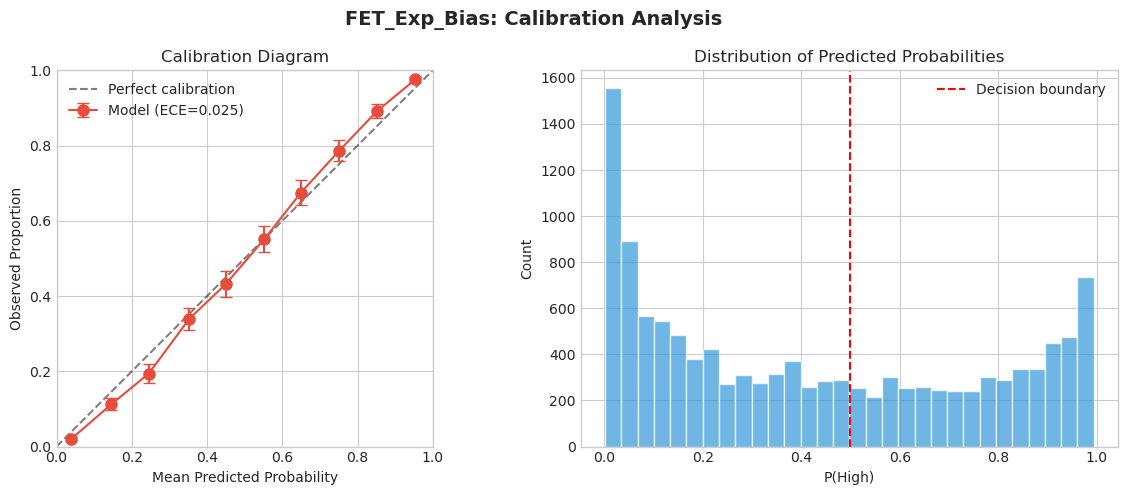

In [18]:
# Calibration plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calibration diagram
ax = axes[0]
cal_df = winning_metrics['calibration_data']

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.errorbar(
    cal_df['predicted_mean'], 
    cal_df['observed_mean'],
    yerr=1.96 * np.sqrt(cal_df['observed_mean'] * (1 - cal_df['observed_mean']) / cal_df['n_trials']),
    fmt='o-', color='#e74c3c', markersize=8, capsize=4,
    label=f'Model (ECE={winning_metrics["ECE"]:.3f})'
)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Observed Proportion')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend()
ax.set_title('Calibration Diagram')
ax.set_aspect('equal')

# Prediction histogram
ax = axes[1]
ax.hist(winning_pred_df['p_high'], bins=30, color='#3498db', alpha=0.7, edgecolor='white')
ax.axvline(x=0.5, color='red', linestyle='--', label='Decision boundary')
ax.set_xlabel('P(High)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Probabilities')
ax.legend()

plt.suptitle(f'{winning_model_name}: Calibration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'winning_model_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

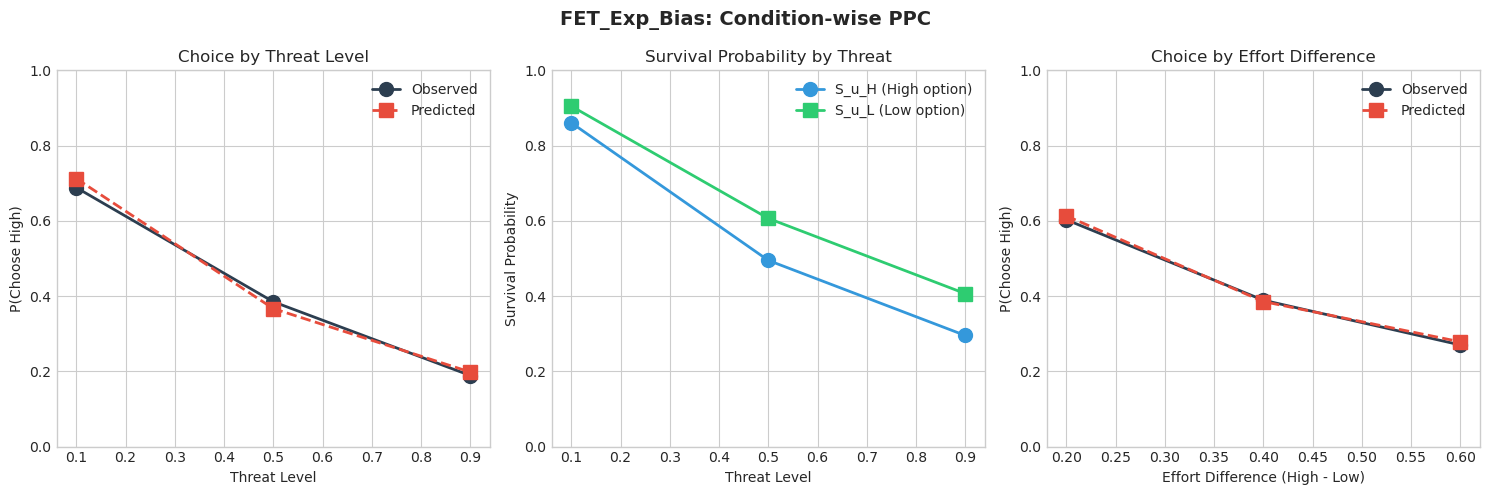

In [19]:
# Condition-wise PPC: Effect of Threat
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Merge predictions with data
plot_data = data.copy()
plot_data['p_high'] = winning_pred_df['p_high']
plot_data['S_u_H'] = winning_pred_df['S_u_H']
plot_data['S_u_L'] = winning_pred_df['S_u_L']

# Group by threat level
threat_summary = plot_data.groupby('threat').agg({
    'choice': 'mean',
    'p_high': 'mean',
    'S_u_H': 'mean',
    'S_u_L': 'mean'
}).reset_index()

# Plot 1: Choice probability by threat
ax = axes[0]
ax.plot(threat_summary['threat'], threat_summary['choice'], 'o-', 
        color='#2c3e50', markersize=10, linewidth=2, label='Observed')
ax.plot(threat_summary['threat'], threat_summary['p_high'], 's--', 
        color='#e74c3c', markersize=10, linewidth=2, label='Predicted')
ax.set_xlabel('Threat Level')
ax.set_ylabel('P(Choose High)')
ax.set_title('Choice by Threat Level')
ax.legend()
ax.set_ylim([0, 1])

# Plot 2: Survival probabilities by threat
ax = axes[1]
ax.plot(threat_summary['threat'], threat_summary['S_u_H'], 'o-', 
        color='#3498db', markersize=10, linewidth=2, label='S_u_H (High option)')
ax.plot(threat_summary['threat'], threat_summary['S_u_L'], 's-', 
        color='#2ecc71', markersize=10, linewidth=2, label='S_u_L (Low option)')
ax.set_xlabel('Threat Level')
ax.set_ylabel('Survival Probability')
ax.set_title('Survival Probability by Threat')
ax.legend()
ax.set_ylim([0, 1])

# Plot 3: Effort effect
ax = axes[2]
plot_data['effort_diff'] = plot_data['effort_H'] - plot_data['effort_L']
plot_data['effort_bin'] = pd.cut(plot_data['effort_diff'], bins=5)

effort_summary = plot_data.groupby('effort_bin', observed=True).agg({
    'choice': 'mean',
    'p_high': 'mean',
    'effort_diff': 'mean'
}).reset_index()

ax.plot(effort_summary['effort_diff'], effort_summary['choice'], 'o-', 
        color='#2c3e50', markersize=10, linewidth=2, label='Observed')
ax.plot(effort_summary['effort_diff'], effort_summary['p_high'], 's--', 
        color='#e74c3c', markersize=10, linewidth=2, label='Predicted')
ax.set_xlabel('Effort Difference (High - Low)')
ax.set_ylabel('P(Choose High)')
ax.set_title('Choice by Effort Difference')
ax.legend()
ax.set_ylim([0, 1])

plt.suptitle(f'{winning_model_name}: Condition-wise PPC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'winning_model_conditionwise_ppc.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Subject-level fit metrics
subj_metrics = ppc.compute_subject_metrics(data, winning_pred_df)

print("Subject-level fit metrics:")
print(subj_metrics.describe())

Subject-level fit metrics:
             subj    accuracy       brier     log_lik  mean_p_high  \
count  270.000000  270.000000  270.000000  270.000000   270.000000   
mean   135.500000    0.834156    0.115780  -16.383201     0.425740   
std     78.086491    0.086684    0.048272    5.881951     0.177967   
min      1.000000    0.555556    0.021127  -30.529809     0.100143   
25%     68.250000    0.777778    0.075683  -20.962999     0.294354   
50%    135.500000    0.844444    0.115057  -16.368299     0.416463   
75%    202.750000    0.888889    0.151779  -11.341974     0.564064   
max    270.000000    1.000000    0.242868   -4.452472     0.936689   

       mean_choice  n_trials  
count   270.000000     270.0  
mean      0.420741      45.0  
std       0.201307       0.0  
min       0.000000      45.0  
25%       0.288889      45.0  
50%       0.422222      45.0  
75%       0.577778      45.0  
max       0.977778      45.0  


/home/nokada/projects/LIMA_Analysis_clean/Code/Modeling/behavior_2/CLEAN_ATTEMPT/fet_models/ppc.py:257: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return merged.groupby('subj').apply(subj_metrics).reset_index()


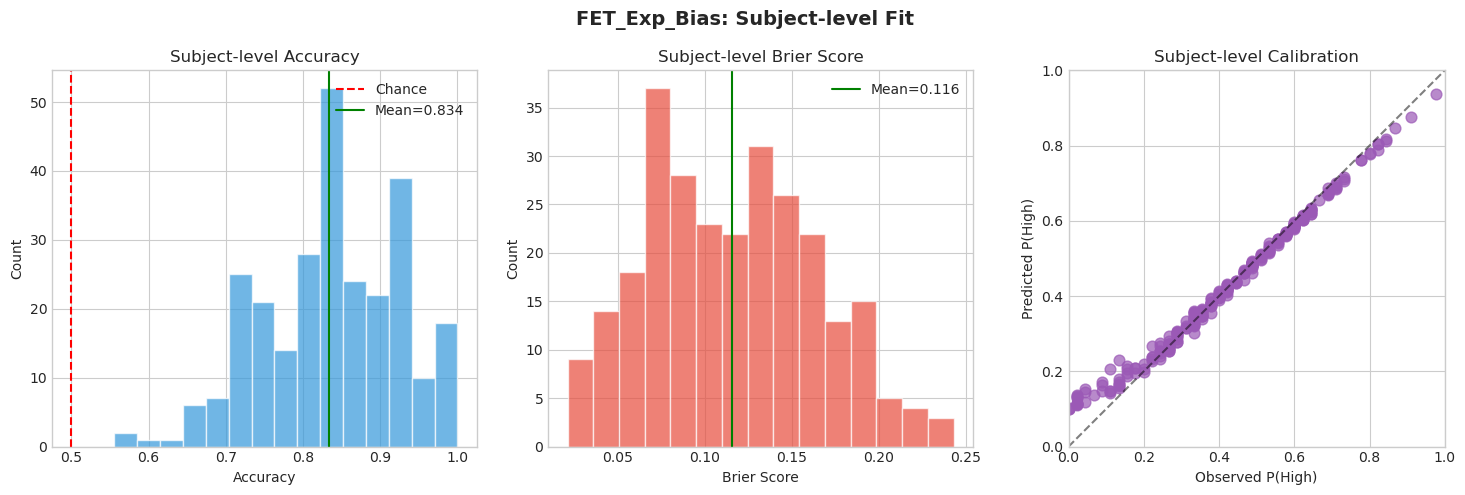

In [21]:
# Subject-level fit visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy distribution
ax = axes[0]
ax.hist(subj_metrics['accuracy'], bins=15, color='#3498db', alpha=0.7, edgecolor='white')
ax.axvline(x=0.5, color='red', linestyle='--', label='Chance')
ax.axvline(x=subj_metrics['accuracy'].mean(), color='green', linestyle='-', 
           label=f'Mean={subj_metrics["accuracy"].mean():.3f}')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Count')
ax.set_title('Subject-level Accuracy')
ax.legend()

# Brier score distribution
ax = axes[1]
ax.hist(subj_metrics['brier'], bins=15, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(x=subj_metrics['brier'].mean(), color='green', linestyle='-',
           label=f'Mean={subj_metrics["brier"].mean():.3f}')
ax.set_xlabel('Brier Score')
ax.set_ylabel('Count')
ax.set_title('Subject-level Brier Score')
ax.legend()

# Predicted vs Observed
ax = axes[2]
ax.scatter(subj_metrics['mean_choice'], subj_metrics['mean_p_high'], 
           s=60, alpha=0.7, c='#9b59b6')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Observed P(High)')
ax.set_ylabel('Predicted P(High)')
ax.set_title('Subject-level Calibration')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_aspect('equal')

plt.suptitle(f'{winning_model_name}: Subject-level Fit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'winning_model_subject_fit.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Extract Subject-Level Parameters

In [22]:
# Get population parameters
pop_params = winning_fitter.get_population_params()

print("Population-level Parameters:")
print("="*60)
print(pop_params.to_string(index=False))

Population-level Parameters:
 parameter     mean   median      std  hdi_lower  hdi_upper
       tau 0.572923 0.572228 0.042056   0.492449   0.649861
      mu_k 1.202619 1.201556 0.134899   0.956702   1.461669
   sigma_k 1.047831 1.042022 0.104943   0.851266   1.244480
      mu_z 0.471576 0.471111 0.045756   0.387284   0.558387
   sigma_z 0.607590 0.605220 0.055273   0.506327   0.711191
   mu_beta 2.307856 2.307909 0.133354   2.051599   2.553900
sigma_beta 1.801932 1.799155 0.104487   1.608105   2.000423


In [23]:
# Get subject-level parameters
# Available parameters depend on the model
available_params = [k for k in winning_fitter.model.posterior_samples.keys() 
                    if k in ['k', 'z', 'beta']]

print(f"Available subject-level parameters: {available_params}")

subject_params = {}
for param in available_params:
    subject_params[param] = winning_fitter.get_subject_params(param)
    print(f"\n{param.upper()} parameters:")
    print(subject_params[param].head(10))

Available subject-level parameters: ['beta', 'k', 'z']

BETA parameters:
   subject      mean    median       std  hdi_lower  hdi_upper
0        1  4.336297  4.303131  1.075939   2.327384   6.385858
1        2  2.364350  2.323061  0.998968   0.569726   4.304195
2        3  0.257728  0.260761  0.795309  -1.233899   1.745532
3        4  4.168886  4.147070  0.963631   2.387553   6.016944
4        5  0.819823  0.840591  0.801926  -0.623425   2.363523
5        6  3.816066  3.773522  1.053790   1.884287   5.800249
6        7  2.885472  2.861453  0.916275   1.217704   4.672959
7        8  3.443095  3.372858  1.076168   1.503329   5.543115
8        9  6.516973  6.478601  1.277821   4.108696   8.864916
9       10  1.803243  1.784994  0.826340   0.255397   3.369390

K parameters:
   subject      mean    median       std  hdi_lower  hdi_upper
0        1  1.054012  1.016721  0.400539   0.335728   1.796129
1        2  3.628321  3.574796  1.138025   1.900982   5.000000
2        3  2.151211  1.983063

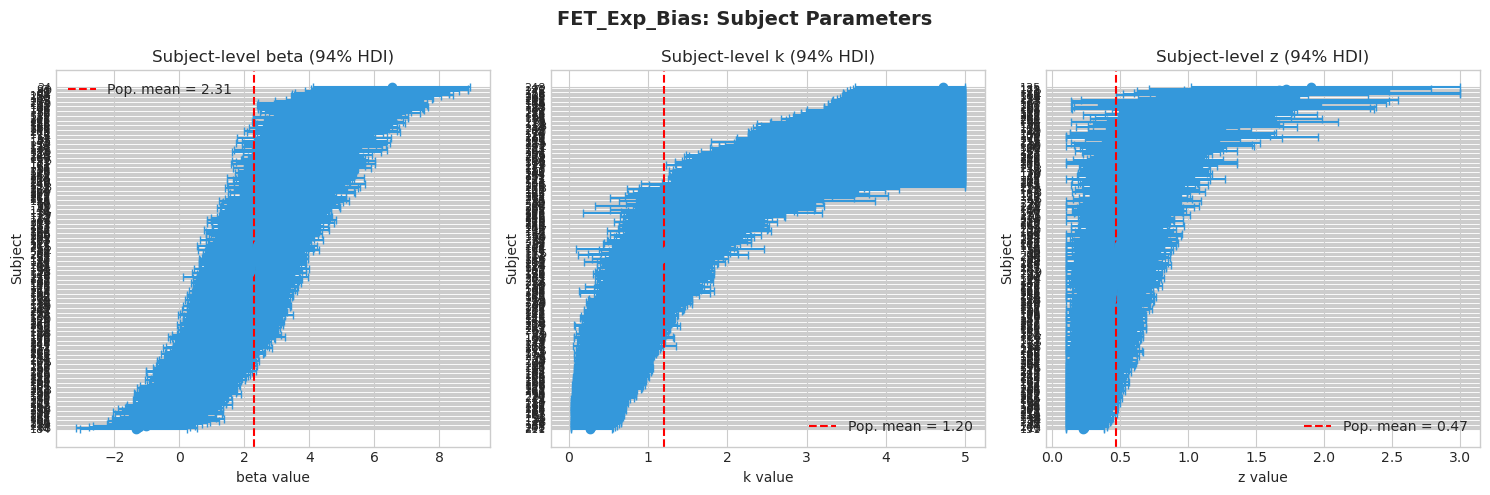

In [27]:
# Visualize subject-level parameters
n_params = len(available_params)
fig, axes = plt.subplots(1, n_params, figsize=(5*n_params, 5))

if n_params == 1:
    axes = [axes]

for i, param in enumerate(available_params):
    ax = axes[i]
    param_df = subject_params[param].sort_values('mean')
    
    # Plot with HDI error bars
    y_pos = np.arange(len(param_df))
    ax.errorbar(param_df['mean'], y_pos, 
                xerr=[param_df['mean'] - param_df['hdi_lower'], 
                      param_df['hdi_upper'] - param_df['mean']],
                fmt='o', color='#3498db', capsize=3, markersize=6)
    
    # Population mean
    if f'mu_{param}' in pop_params['parameter'].values:
        pop_mean = pop_params[pop_params['parameter'] == f'mu_{param}']['mean'].values[0]
        ax.axvline(x=pop_mean, color='red', linestyle='--', 
                   label=f'Pop. mean = {pop_mean:.2f}')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(param_df['subject'], fontsize=8)
    ax.set_xlabel(f'{param} value')
    ax.set_ylabel('Subject')
    ax.set_title(f'Subject-level {param} (94% HDI)')
    ax.legend()

plt.suptitle(f'{winning_model_name}: Subject Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'winning_model_subject_params.png', dpi=300, bbox_inches='tight')
plt.show()

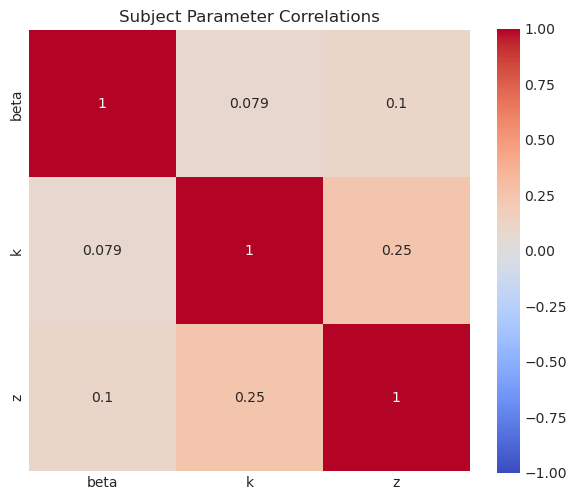


Parameter correlations:
          beta         k         z
beta  1.000000  0.079086  0.104656
k     0.079086  1.000000  0.246132
z     0.104656  0.246132  1.000000


In [28]:
# Parameter correlations (if multiple subject-level params available)
if len(available_params) >= 2:
    # Combine into single DataFrame
    combined_params = subject_params[available_params[0]][['subject', 'mean']].rename(
        columns={'mean': available_params[0]})
    
    for param in available_params[1:]:
        param_means = subject_params[param][['subject', 'mean']].rename(
            columns={'mean': param})
        combined_params = combined_params.merge(param_means, on='subject')
    
    # Correlation matrix
    corr_matrix = combined_params[available_params].corr()
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title('Subject Parameter Correlations')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'parameter_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nParameter correlations:")
    print(corr_matrix)

## 8. Save Results

In [30]:
# Save comparison table (includes WAIC)
comparison_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'model_comparison.csv'}")

# Save winning model predictions
winning_pred_df.to_csv(OUTPUT_DIR / f'{winning_model_name}_predictions.csv', index=False)
print(f"Saved: {OUTPUT_DIR / f'{winning_model_name}_predictions.csv'}")

# Save subject-level metrics
subj_metrics.to_csv(OUTPUT_DIR / f'{winning_model_name}_subject_metrics.csv', index=False)
print(f"Saved: {OUTPUT_DIR / f'{winning_model_name}_subject_metrics.csv'}")

# Save subject-level parameters
for param in available_params:
    subject_params[param].to_csv(OUTPUT_DIR / f'{winning_model_name}_{param}_params.csv', index=False)
    print(f"Saved: {OUTPUT_DIR / f'{winning_model_name}_{param}_params.csv'}")

# Save population parameters
pop_params.to_csv(OUTPUT_DIR / f'{winning_model_name}_population_params.csv', index=False)
print(f"Saved: {OUTPUT_DIR / f'{winning_model_name}_population_params.csv'}")

# Save WAIC results for all models
waic_results = []
for name, res in comparison_results.items():
    w = res['waic']
    waic_results.append({
        'Model': name,
        'WAIC': w['WAIC'],
        'lppd': w['lppd'],
        'p_waic': w['p_waic'],
        'se': w['se']
    })
waic_df = pd.DataFrame(waic_results).sort_values('WAIC')
waic_df.to_csv(OUTPUT_DIR / 'waic_comparison.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'waic_comparison.csv'}")

print(f"\n✓ All results saved to: {OUTPUT_DIR}")

Saved: results/model_comparison.csv
Saved: results/FET_Exp_Bias_predictions.csv
Saved: results/FET_Exp_Bias_subject_metrics.csv
Saved: results/FET_Exp_Bias_beta_params.csv
Saved: results/FET_Exp_Bias_k_params.csv
Saved: results/FET_Exp_Bias_z_params.csv
Saved: results/FET_Exp_Bias_population_params.csv
Saved: results/waic_comparison.csv

✓ All results saved to: results


## 9. Summary

In [31]:
print("="*70)
print("ANALYSIS SUMMARY")
print("="*70)
print(f"\nData: {len(data)} trials, {data['subj'].nunique()} subjects")
print(f"\nModels compared: {len(fitted_models)}")
for i, row in comparison_df.iterrows():
    marker = '★' if i == 0 else ' '
    print(f"  {marker} {row['Model']}: WAIC = {row['WAIC']:.1f}, dWAIC = {row['dWAIC']:.1f}")

print(f"\n{'='*70}")
print(f"WINNING MODEL: {winning_model_name}")
print(f"{'='*70}")
print(f"  WAIC:        {winning_waic['WAIC']:.2f} (SE: {winning_waic['se']:.2f})")
print(f"  p_waic:      {winning_waic['p_waic']:.2f}")
print(f"  McFadden R²: {winning_metrics['McFadden_R2']:.4f}")
print(f"  Accuracy:    {winning_metrics['Accuracy']:.4f}")
print(f"  AUC:         {winning_metrics['AUC']:.4f}")
print(f"  Brier:       {winning_metrics['Brier']:.4f}")
print(f"  ECE:         {winning_metrics['ECE']:.4f}")

print(f"\nSubject-level parameters: {available_params}")
print(f"\nResults saved to: {OUTPUT_DIR}")
print("="*70)

ANALYSIS SUMMARY

Data: 12150 trials, 270 subjects

Models compared: 7
  ★ FET_Exp_Bias: WAIC = 9845.4, dWAIC = 0.0
    FET_Exponential: WAIC = 11770.3, dWAIC = 1925.0
    FET_Quadratic: WAIC = 11889.9, dWAIC = 2044.6
    FET_Hyperbolic: WAIC = 12012.1, dWAIC = 2166.8
    FET_Linear: WAIC = 12432.3, dWAIC = 2587.0
    Threat_Only: WAIC = 13300.9, dWAIC = 3455.5
    Effort_Only: WAIC = 15375.3, dWAIC = 5530.0

WINNING MODEL: FET_Exp_Bias
  WAIC:        9845.35 (SE: 120.99)
  p_waic:      499.21
  McFadden R²: 0.4650
  Accuracy:    0.8342
  AUC:         0.9164
  Brier:       0.1158
  ECE:         0.0251

Subject-level parameters: ['beta', 'k', 'z']

Results saved to: results
